In [ ]:
import pandas as pd

In [ ]:
#Step 1: Preparation of data

In [ ]:
# Select the variables that are relevant only
variables = ["kohde", "jasen", "pvknro", "sp", "IKAL1", "ASALUE",
             "V1", "V21", "V32", "V40", "H1a_A", "H1h_A"]

In [ ]:
#Loading the dataset
data = pd.read_csv("/content/habits (1).data", delimiter=";", na_values="?")

In [ ]:
data = data[variables]

In [ ]:
print("Preview of the dataset:")
print(data.head())

Preview of the dataset:
   kohde  jasen  pvknro  sp  IKAL1  ASALUE     V1    V21    V32    V40  H1a_A  \
0  50007      2       2   2      6     3.0    580      0    430      0    1.0   
1  50009      1       1   2      7     1.0      0      0    560      0    1.0   
2  50015      1       1   1      8     3.0      0      0    450      0    2.0   
3  50032      2       1   1      8     2.0      0      0    530      0    2.0   
4  50033      1       1   2      8     1.0  00:00  00:00  07:20  00:00    2.0   

   H1h_A  
0    1.0  
1    1.0  
2    1.0  
3    2.0  
4    2.0  


In [ ]:
print("Summary of the dataset:")
print(data.info())

Summary of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   kohde   393 non-null    int64  
 1   jasen   393 non-null    int64  
 2   pvknro  393 non-null    int64  
 3   sp      393 non-null    int64  
 4   IKAL1   393 non-null    int64  
 5   ASALUE  392 non-null    float64
 6   V1      391 non-null    object 
 7   V21     391 non-null    object 
 8   V32     388 non-null    object 
 9   V40     390 non-null    object 
 10  H1a_A   369 non-null    float64
 11  H1h_A   370 non-null    float64
dtypes: float64(3), int64(5), object(4)
memory usage: 37.0+ KB
None


In [ ]:
#Identify the missing values in the dataset
missing_values_summary = data.isnull().sum()
print("Missing values per column:")
print(missing_values_summary)

Missing values per column:
kohde      0
jasen      0
pvknro     0
sp         0
IKAL1      0
ASALUE     1
V1         2
V21        2
V32        5
V40        3
H1a_A     24
H1h_A     23
dtype: int64


In [ ]:
#Replace the missing values with the median
activity_columns = ["V1", "V21", "V32", "V40"]
for col in activity_columns:
    #pd.to_numeric() function converts each column to numeric, using errors='coerce' to turn invalid or non-numeric values into NaN
    data[col] = pd.to_numeric(data[col], errors='coerce')
    data[col] = data[col].fillna(data[col].median())

In [ ]:
print("Updated dataset summary after handling missing values:")
print(data[activity_columns].describe())

Updated dataset summary after handling missing values:
               V1         V21         V32         V40
count  393.000000  393.000000  393.000000  393.000000
mean   113.715013    9.160305  510.839695    3.053435
std    209.290444   36.736198  102.504640   35.273562
min      0.000000    0.000000  110.000000    0.000000
25%      0.000000    0.000000  460.000000    0.000000
50%      0.000000    0.000000  510.000000    0.000000
75%     50.000000    0.000000  560.000000    0.000000
max    830.000000  350.000000  920.000000  480.000000


In [ ]:
# Step 2: Use of descriptive statistics to summarize the data

In [ ]:
# Summarize the activity durations in terms of count, mean, standard deviation, min, max, and quartiles
numeric_columns = ["V1", "V21", "V32", "V40"]
print("Descriptive statistics for numeric variables (activity durations in minutes):")
print(data[numeric_columns].describe())

Descriptive statistics for numeric variables (activity durations in minutes):
               V1         V21         V32         V40
count  393.000000  393.000000  393.000000  393.000000
mean   113.715013    9.160305  510.839695    3.053435
std    209.290444   36.736198  102.504640   35.273562
min      0.000000    0.000000  110.000000    0.000000
25%      0.000000    0.000000  460.000000    0.000000
50%      0.000000    0.000000  510.000000    0.000000
75%     50.000000    0.000000  560.000000    0.000000
max    830.000000  350.000000  920.000000  480.000000


In [ ]:
# Convert demographic and activity-related categorical columns to appropriate types
categorical_columns = ["sp", "IKAL1", "ASALUE", "H1a_A", "H1h_A"]
print("Frequency distribution for categorical variables:")
for col in categorical_columns:
    print(f"\n{col} - Frequency distribution:")
    print(data[col].value_counts())

Frequency distribution for categorical variables:

sp - Frequency distribution:
sp
2    215
1    178
Name: count, dtype: int64

IKAL1 - Frequency distribution:
IKAL1
6    92
7    90
5    62
8    55
4    51
9    30
3    13
Name: count, dtype: int64

ASALUE - Frequency distribution:
ASALUE
1.0    249
3.0     82
2.0     61
Name: count, dtype: int64

H1a_A - Frequency distribution:
H1a_A
2.0      198
1.0      165
120.0      2
0.0        2
180.0      1
60.0       1
Name: count, dtype: int64

H1h_A - Frequency distribution:
H1h_A
1.0    247
2.0    117
0.0      6
Name: count, dtype: int64


In [ ]:
# Compare average activity durations between genders (sp)
print("Average time spent on activities by gender:")
gender_group = data.groupby("sp")[numeric_columns].mean()
print(gender_group)

Average time spent on activities by gender:
            V1        V21         V32       V40
sp                                             
1   130.561798   6.516854  513.146067  0.000000
2    99.767442  11.348837  508.930233  5.581395


In [ ]:
# Compare average activity durations across different living environments (ASALUE)
print("Average time spent on activities by living environment:")
environment_group = data.groupby("ASALUE")[numeric_columns].mean()
print(environment_group)

Average time spent on activities by living environment:
                V1        V21         V32       V40
ASALUE                                             
1.0     105.662651   6.546185  512.329317  4.819277
2.0     118.688525  11.311475  508.360656  0.000000
3.0     135.853659  15.609756  503.658537  0.000000


In [ ]:
# Step 3: Characterize individuals using clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
# Select activity variables and demographic features for clustering
clustering_columns = ["V1", "V21", "V32", "V40", "sp", "IKAL1", "ASALUE"]
cluster_data = data[clustering_columns].copy()

In [ ]:
categorical_columns = ["sp", "IKAL1", "ASALUE"]
for col in categorical_columns:
    cluster_data[col] = data[col].astype("category")
    cluster_data[col] = cluster_data[col].cat.codes

In [ ]:
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

In [ ]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_data_scaled)
    inertia.append(kmeans.inertia_)

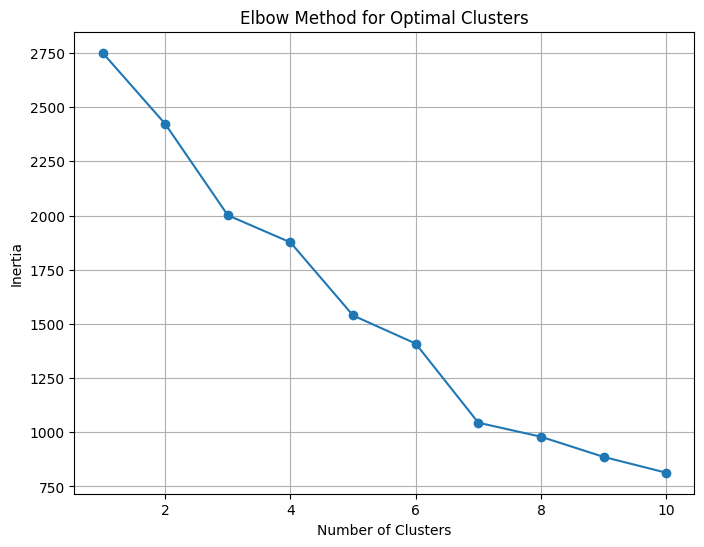

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [ ]:
#Apply k-means clustering with the optimal number of clusters to assign individuals into groups
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
data["Cluster"] = kmeans.fit_predict(cluster_data_scaled)

In [ ]:
#Display cluster centers, sizes, and assigned clusters to individuals
print("Cluster Centers (Standardized):")
print(kmeans.cluster_centers_)

Cluster Centers (Standardized):
[[-5.03908867e-01 -2.13330435e-01  2.31030341e-01 -8.66747543e-02
   5.91888427e-04  2.19425218e-01 -5.77323260e-02]
 [-5.26942281e-01  4.48115778e+00  3.36610348e-02 -8.66747543e-02
   4.79410409e-01 -1.24910518e+00  4.38916952e-01]
 [ 1.60628956e+00 -2.06067532e-02 -7.05477677e-01  2.75699484e-01
  -7.31961056e-02 -4.79241644e-01  1.09668889e-01]]


In [ ]:
print("Cluster Size:")
print(data["Cluster"].value_counts())

Cluster Size:
Cluster
0    285
2     94
1     14
Name: count, dtype: int64


In [ ]:
print("Preview of data with cluster assignments:")
print(data[["kohde", "jasen", "Cluster"]].head())

Preview of data with cluster assignments:
   kohde  jasen  Cluster
0  50007      2        2
1  50009      1        0
2  50015      1        0
3  50032      2        0
4  50033      1        0


In [ ]:
# Step 4: Find the average time spent on each activity by households

In [ ]:
#Compute the mean of each activity column, which represents the average time spent on activities across all households
activity_columns = ["V1", "V21", "V32", "V40"]
average_time_per_activity = data[activity_columns].mean()

In [ ]:
print("Average time spent on activities (in minutes):")
print(average_time_per_activity)

Average time spent on activities (in minutes):
V1     113.715013
V21      9.160305
V32    510.839695
V40      3.053435
dtype: float64


In [ ]:
import matplotlib.pyplot as plt

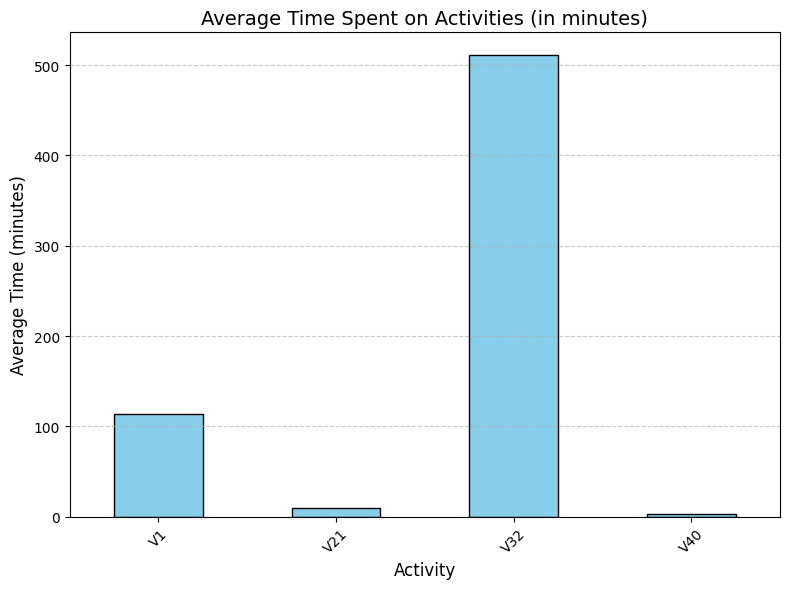

In [ ]:
plt.figure(figsize=(8, 6))
average_time_per_activity.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Average Time Spent on Activities (in minutes)", fontsize=14)
plt.xlabel("Activity", fontsize=12)
plt.ylabel("Average Time (minutes)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Compare activity durations between men and women

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
#Calculate the average time spent on each activity for men (sp=1) and women (sp=2)
gender_groups = data.groupby("sp")[["V1", "V21", "V32", "V40"]]

In [ ]:
average_time_by_gender = gender_groups.mean()
print("Average time spent on activities by gender (in minutes):")
print(average_time_by_gender)

Average time spent on activities by gender (in minutes):
            V1        V21         V32       V40
sp                                             
1   130.561798   6.516854  513.146067  0.000000
2    99.767442  11.348837  508.930233  5.581395


In [ ]:
# Perform Welch's t-tests for each activity to test for differences in mean time spent between men and women
# We used Welch's t-test as it does not assume equal variances
print("T-test results for gender differences in time spent on activities:")
activity_columns = ["V1", "V21", "V32", "V40"]
for activity in activity_columns:
    male_time = data[data["sp"] == 1][activity].dropna()
    female_time = data[data["sp"] == 2][activity].dropna()
    t_stat, p_value = ttest_ind(male_time, female_time, equal_var=False)
    print(f"{activity}: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")

T-test results for gender differences in time spent on activities:
V1: t-statistic = 1.437, p-value = 0.152
V21: t-statistic = -1.370, p-value = 0.172
V32: t-statistic = 0.403, p-value = 0.687
V40: t-statistic = -1.720, p-value = 0.087


<Figure size 1000x600 with 0 Axes>

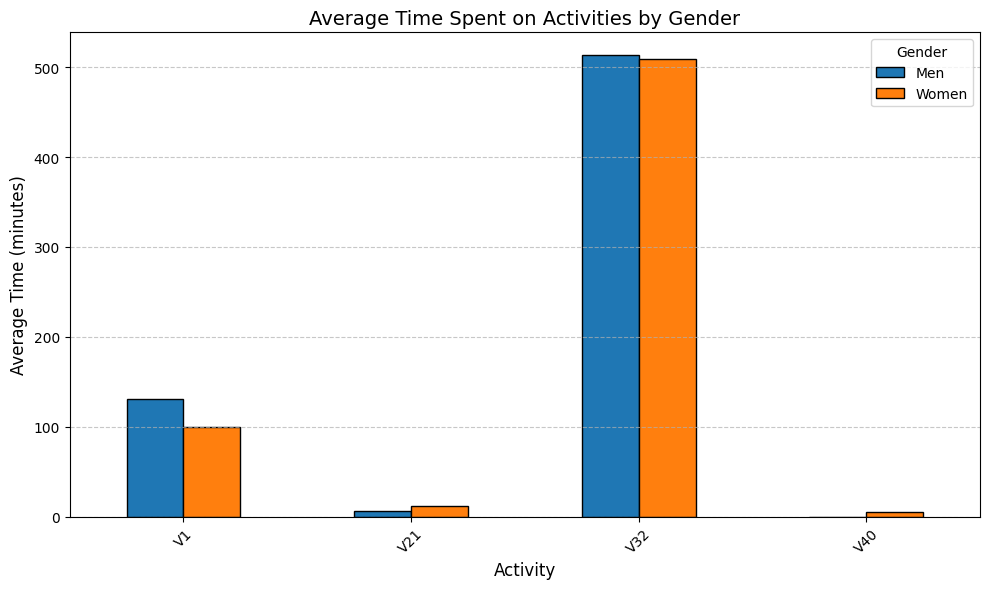

In [ ]:
plt.figure(figsize=(10, 6))
average_time_by_gender.T.plot(kind="bar", figsize=(10, 6), edgecolor="black")
plt.title("Average Time Spent on Activities by Gender", fontsize=14)
plt.xlabel("Activity", fontsize=12)
plt.ylabel("Average Time (minutes)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(["Men", "Women"], title="Gender", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Step 6: Compare activity durations across living environments

In [ ]:
from scipy.stats import f_oneway

In [ ]:
environment_groups = data.groupby("ASALUE")[["V1", "V21", "V32", "V40"]]

In [ ]:
# Calculates the average time spent on each activity (V1, V21, V32, V40) for each living environment (ASALUE)
average_time_by_environment = environment_groups.mean()
print("\nAverage time spent on activities by living environment (in minutes):")
print(average_time_by_environment)


Average time spent on activities by living environment (in minutes):
                V1        V21         V32       V40
ASALUE                                             
1.0     105.662651   6.546185  512.329317  4.819277
2.0     118.688525  11.311475  508.360656  0.000000
3.0     135.853659  15.609756  503.658537  0.000000


In [ ]:
data["ASALUE"] = data["ASALUE"].astype("category")

In [ ]:
# Conduct a one-way ANOVA to test for significant differences in activity means in the three living environments
print("ANOVA results for differences in time spent by living environment:")
for activity in ["V1", "V21", "V32", "V40"]:
    groups = [data[data["ASALUE"] == category][activity].dropna() for category in data["ASALUE"].cat.categories]
    f_stat, p_value = f_oneway(*groups)
    print(f"{activity}: F-statistic = {f_stat:.3f}, p-value = {p_value:.3f}")

ANOVA results for differences in time spent by living environment:
V1: F-statistic = 0.658, p-value = 0.519
V21: F-statistic = 2.004, p-value = 0.136
V32: F-statistic = 0.235, p-value = 0.791
V40: F-statistic = 0.845, p-value = 0.430


In [ ]:
# Step 7: Analyze the relationships between the activity variables

In [ ]:
import seaborn as sns

In [ ]:
activity_columns = ["V1", "V21", "V32", "V40"]

In [ ]:
# Compute the pairwise correlation coefficients between the activity variables to quantify their relationships.
correlation_matrix = data[activity_columns].corr()

In [ ]:
print("Correlation matrix for activities:")
print(correlation_matrix)

Correlation matrix for activities:
           V1       V21       V32       V40
V1   1.000000 -0.005831 -0.293261 -0.047154
V21 -0.005831  1.000000  0.016988 -0.021640
V32 -0.293261  0.016988  1.000000 -0.056801
V40 -0.047154 -0.021640 -0.056801  1.000000


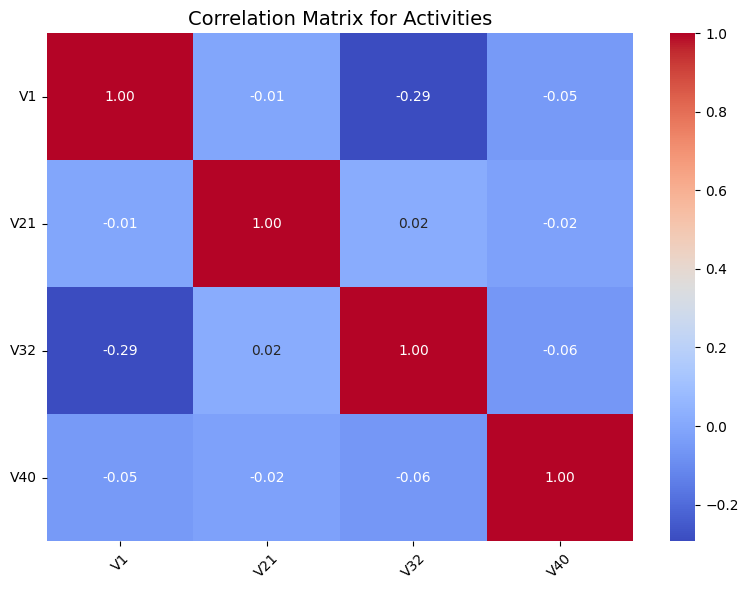

In [ ]:
# Display the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Matrix for Activities", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()